In [1]:
import numpy as np
import pandas as pd
from scipy import fft
import matplotlib.pyplot as plt

In [2]:
traces = pd.read_csv("../traces.dat", delimiter="\t")
tc = traces[6000:-6000].reset_index(drop=True).values.flatten()

def remove_signal(trace, sig_window):
    sig = np.argmax(trace)
    return np.delete(trace, np.arange(sig-sig_window,sig+sig_window+1))

In [3]:
noise = remove_signal(tc, 4)

In [4]:
N = len(noise)
dt = 5*10**(-9)
fourier = fft.rfft(noise)
nu = np.sqrt(2)*dt*fourier
omega = 2*np.pi * np.fft.rfftfreq(N, d=dt)

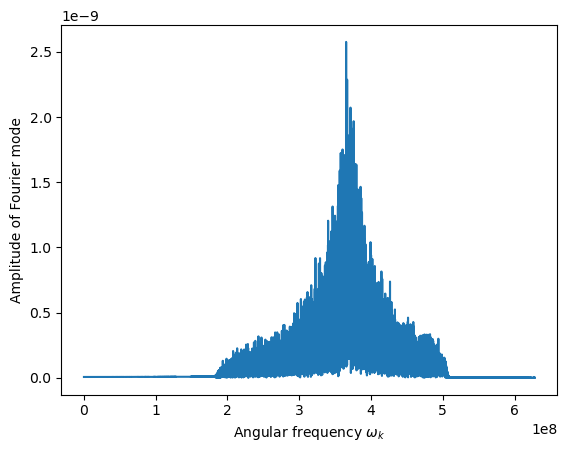

In [5]:
plt.plot(omega, np.abs(nu))
plt.ylabel("Amplitude of Fourier mode")
plt.xlabel(r"Angular frequency $\omega_k$")
plt.show()

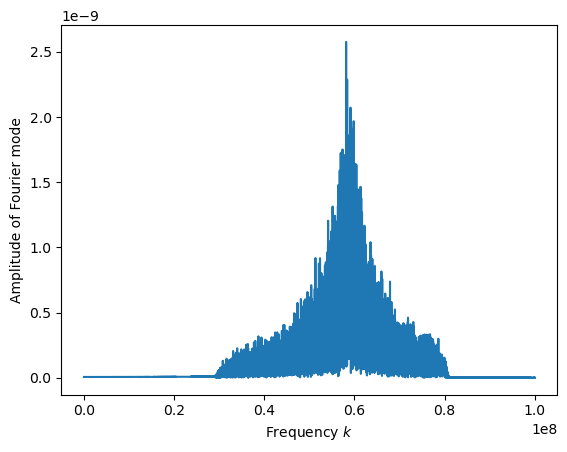

In [8]:
plt.plot(omega/(2*np.pi), np.abs(nu))
plt.ylabel("Amplitude of Fourier mode")
plt.xlabel(r"Frequency $k$")
plt.show()

In [ ]:
def cov_question(trace, duration):

    if N==0:
        return np.zeros((duration, duration))200"

    cov = np.empty((duration, duration))
    for i in range(duration):
        for j in range(duration-i):
            cov[i, i+j] = np.sum(diffs[:,i]*diffs[:,j])/N
            cov[i+j,j] = cov[i,i+j]
